The Reddit hyperlink network represents the directed connections between two subreddits (a subreddit is a community on Reddit). The network is extracted from publicly available Reddit data of 2.5 years from Jan 2014 to April 2017. 

The subreddit-to-subreddit hyperlink network is extracted from the posts that create hyperlinks from one subreddit to another. We say a hyperlink originates from a post in the source community and links to a post in the target community. Each hyperlink is annotated with three properties: the timestamp, the sentiment of the source community post towards the target community post, and the text property vector of the source post.  
Note that each post has a title and a body. The hyperlink can be present in either the title of the post or in the body.

- The network is directed, signed, temporal, and attributed.
- EDA is performed on the static network that occurs after the last timestamped edge is added.

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

dataset = ["dataset/soc-redditHyperlinks-body.tsv", "dataset/soc-redditHyperlinks-title.tsv"]

In [2]:
frames = []
for subset in dataset:
    df = pd.read_csv(subset, sep='\t', usecols=[0, 1],
                    names=["src", "tgt"], header=0)
    frames.append(df)
df = pd.concat(frames, ignore_index=True)

G = nx.from_pandas_edgelist(df, source='src', target='tgt', create_using=nx.DiGraph())

density = nx.density(G)
is_strongly_connected = nx.is_strongly_connected(G)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", density)
print("Sparsity:", 1 - density)
print("Strongly Connected:", is_strongly_connected)

Nodes: 67180
Edges: 339643
Density: 7.525738678606207e-05
Sparsity: 0.999924742613214
Strongly Connected: False


In [3]:
scc = list(nx.strongly_connected_components(G))
wcc = list(nx.weakly_connected_components(G))
print("Number of Strongly Connected Components:", len(scc))
print("Number of Weakly Connected Components:", len(wcc))
print("Giant Strongly Connected Component Size:", len(max(scc, key=len)))
print("Giant Weakly Connected Component Size:", len(max(wcc, key=len)))

Number of Strongly Connected Components: 45564
Number of Weakly Connected Components: 712
Giant Strongly Connected Component Size: 21432
Giant Weakly Connected Component Size: 65648


In [ ]:
# subgraph G2 where node degrees >= 300
nodes_to_keep = [node for node, degree in G.degree() if degree >= 300]
G2 = G.subgraph(nodes_to_keep)
lscc = max(list(nx.strongly_connected_components(G2)), key=len)
lscc_nw = G2.subgraph(lscc)
print("Creating subgraph G2 with nodes having degree >= 300")
print("G2 Nodes:", G2.number_of_nodes())
print("G2 Edges:", G2.number_of_edges())
print("Nodes in G2 LSCC:", lscc_nw.number_of_nodes())
print("Edges in G2 LSCC:", lscc_nw.number_of_edges())

avg_path_length = nx.average_shortest_path_length(lscc_nw)
diameter = nx.diameter(lscc_nw)
print("\nAverage Path Length:", avg_path_length)
print("Diameter:", diameter)

Creating subgraph G2 with nodes having degree >= 300
G2 Nodes: 306
G2 Edges: 23826
Nodes in G2 LSCC: 300
Edges in G2 LSCC: 23303

Average Path Length: 1.7847045707915272
Diameter: 4


In [12]:
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]
print("Avg In/Out Degree:", np.mean(in_degrees))
print("Average Total Degree:", (np.mean(in_degrees) + np.mean(out_degrees)))
print("Min In-Degree:", np.min(in_degrees))
print("Max In-Degree:", np.max(in_degrees), "(Other subreddits have linked to this subreddit the most)")
print("Min Out-Degree:", np.min(out_degrees))
print("Max Out-Degree:", np.max(out_degrees), "(This subreddit has linked to other subreddits the most)")

Avg In/Out Degree: 5.055715986900863
Average Total Degree: 10.111431973801727
Min In-Degree: 0
Max In-Degree: 5448 (Other subreddits have linked to this subreddit the most)
Min Out-Degree: 0
Max Out-Degree: 3111 (This subreddit has linked to other subreddits the most)


In [13]:
transitivity = nx.transitivity(G)
avg_clustering = nx.average_clustering(G)
assortativity = nx.degree_assortativity_coefficient(G)
print("Transitivity:", transitivity)
print("Average Clustering Coefficient:", avg_clustering)
print("Degree Assortativity Coefficient:", assortativity)

Transitivity: 0.058850778565028426
Average Clustering Coefficient: 0.16870989594128227
Degree Assortativity Coefficient: -0.10324534828701039


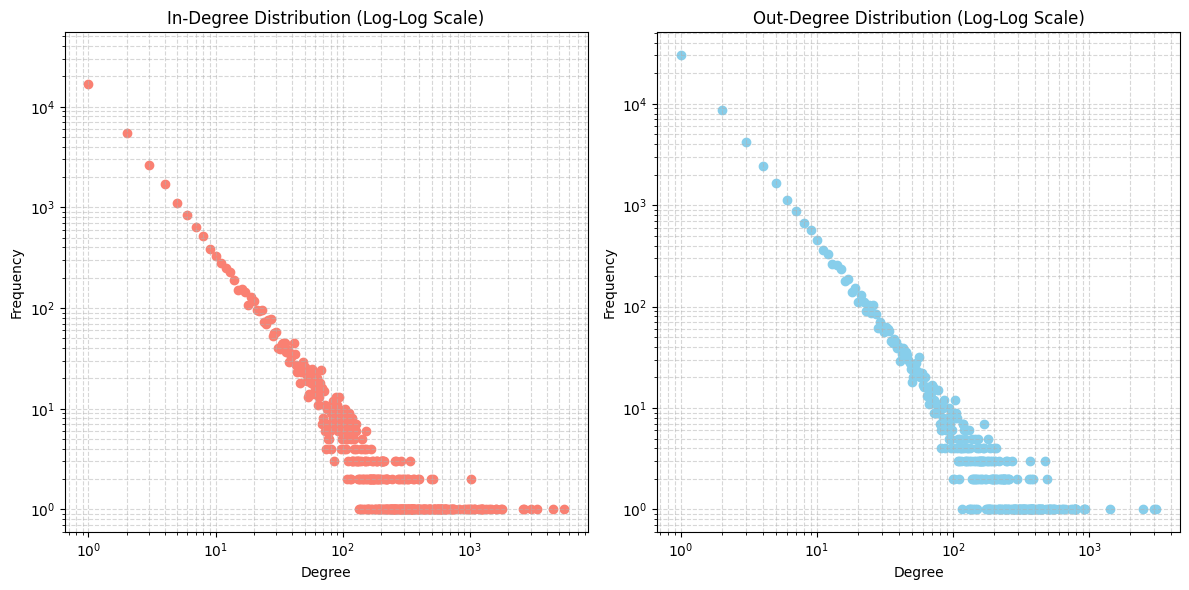

In [14]:
in_counts = Counter(d for n, d in G.in_degree())
out_counts = Counter(d for n, d in G.out_degree())
in_x, in_y = zip(*sorted(in_counts.items()))
out_x, out_y = zip(*sorted(out_counts.items()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(in_x, in_y, color='salmon')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title("In-Degree Distribution (Log-Log Scale)")
ax1.set_xlabel("Degree")
ax1.set_ylabel("Frequency")
ax1.grid(True, which="both", ls="--", alpha=0.5)

ax2.scatter(out_x, out_y, color='skyblue')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title("Out-Degree Distribution (Log-Log Scale)")
ax2.set_xlabel("Degree")
ax2.set_ylabel("Frequency")
ax2.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

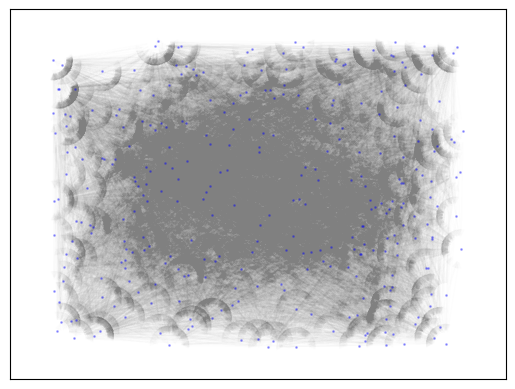

In [3]:
pos = nx.random_layout(G2)
nx.draw_networkx_nodes(G2, pos, node_size=1, node_color='blue', alpha=0.3)
nx.draw_networkx_edges(G2, pos, alpha=0.01, edge_color='gray')
plt.show()